# 06 — Model evolution

**Supplementary Figures 5 and 6** — "Evolution of Model Performance", Parts 1
and 2, printed on pages 32 and 33 of the Supplementary Information.

Eight model families, one row each, two panels per row: the programs a family
generated on the left, the formulae on the right. Within a row the models run
oldest to newest, so a row reads as a family's trajectory. Each panel stacks the
four output *types* as percentages — Known sequence, Pure math, Print, Not
found — and overlays three lines on separate axes: Accuracy, Equivalence, and
the raw count of Valid Instances.

The claim these two figures support is the uncomfortable one in the paper: that
several families get **worse** along their own release order. The stack is how
you see why. A family whose Accuracy line falls while its Known-sequence band
grows is recognising more and solving less; a family whose Not-found band grows
is declining to answer. Both look like degradation in the line and mean
different things in the stack, which is the reason the figure is a stack and not
a line chart.

### What this notebook is checking

These two panels were regenerated on every parity run and, until 2026-09-16,
compared against **nothing** — the gate held their two input CSVs and not the
figures. A change in the plotting code would have passed silently. They are
compared as images now, and this notebook is the readable half of that check.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd

from superarc import REPO_ROOT, evolution as E, parity, plots_dir
from superarc.notebook import preview_pdf

pd.set_option("display.width", 140)
plots_dir()

PosixPath('/Users/alberto/Documents/projects/medLLM/outputs/latest')

## 1. The input

One file, `comparison_models_summary.csv`: 39 model columns against a long index
of `case` × `Measure` × `complexity`. `case` separates the two experiments —
`multiple script` and `multiple formulae` — so both figures come out of one
table.

It is worth being precise about where this file comes from, because an earlier
note in this repository called it hand-maintained and that was wrong. Its
producer is `full_analysis.py`, which wrote it at line 867; the file was added on
2026-04-06 and the producer deleted on 2026-09-11 as superseded analysis code.
Re-running it reproduces 1617 of its 1638 cells. The committed file is what the
figures read, by the author's ruling that closeness to the published plots
decides — see `superarc/model_summary.py`.


In [2]:
raw = pd.read_csv(REPO_ROOT / "comparison_models_summary.csv")
model_cols = [c for c in raw.columns if c not in ("case", "Measure", "complexity")]
print(f"{len(raw)} rows, {len(model_cols)} model columns")
print("cases:   ", sorted(raw["case"].unique()))
print("measures:", sorted(raw["Measure"].unique()))
raw.head(4)

42 rows, 39 model columns
cases:    ['multiple formulae', 'multiple script']
measures: ['Accuracy', 'Equivalence', 'Known sequence', 'Not found', 'Print', 'Pure math', 'Valid Instances']


,case,Measure,complexity,grok-3,deepseek,qwen,gemini,claude-3-5-sonnet,chatgpt-4o,mistral,...,chatgpt_4.5,claude_3.5,gpt_4o,o1_preview,grok_3,claude_3.7,gpt_4o_mini,grok4,gemini_2.5_pro,deepseek_r1_0528
0,multiple formulae,Accuracy,1,0.0,100.000000,100.000000,100.000000,0.0,0.0,100.000000,...,100.000000,100.000000,100.000000,100.0,100.000000,66.666667,73.333333,86.666667,70.000000,100.000000
1,multiple formulae,Accuracy,2,0.0,63.333333,46.666667,33.333333,0.0,0.0,16.666667,...,36.666667,43.333333,46.666667,50.0,53.333333,23.333333,33.333333,16.666667,26.666667,26.666667
2,multiple formulae,Accuracy,3,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,multiple formulae,Equivalence,1,0.0,6.666667,100.000000,43.333333,0.0,0.0,0.000000,...,36.666667,100.000000,40.000000,100.0,93.333333,20.000000,13.333333,16.666667,20.000000,50.000000


## 2. Nine families in the table, eight in the figures

`get_family` sorts every model column into a family. The registry knows nine.
The published script splits the families four and four across the two parts —
and **Cursor is in neither half**, so Cursor-Small has never been drawn.

It is in the data, it is in both output CSVs, and the printed captions name
eight families. So this is a property of the published figure, not a defect to
repair: correcting it would move a published plot. It is shown here because a
family that is in the table and not in the figure is otherwise invisible.


In [3]:
families = pd.Series({m.name: E.get_family(m.name) for m in __import__(
    "superarc.registry", fromlist=["MODELS"]).MODELS}).rename("family")

summary = pd.DataFrame({
    "models": families.groupby(families).size(),
    "drawn": [f in E.FAMILY_ORDER for f in sorted(families.unique())],
    "part": [(1 if f in list(E.FAMILY_ORDER)[:4] else 2) if f in E.FAMILY_ORDER else None
             for f in sorted(families.unique())],
}).sort_values(["drawn", "part"])
summary

,models,drawn,part
family,,,
Cursor,1,False,NaN
Claude,5,True,1.0
Gemini,3,True,1.0
Grok,3,True,1.0
OpenAI,7,True,1.0
DeepSeek,2,True,2.0
Meta,2,True,2.0
Mistral,3,True,2.0
Qwen,2,True,2.0


## 3. The ordering that was collapsed

`FAMILY_ORDER` used to exist twice — once in the registry, once hand-written in
`35_summary_statistics.py` — and the two disagreed. Collapsing two copies blind
is how a figure moves without anyone noticing, so the structural guard refused
the collapse until the two were diffed elementwise.

Six of the eight families were character-for-character identical. Three
differences, all decided:

| difference | verdict |
|---|---|
| the script listed `'Grok'` first | **inert** — no model of that name exists, so every later rank shifted by one, uniformly |
| the script listed `'DeepSeek-R1-0525'` | **inert** — annotated "included both versions for safety"; in no dataset |
| `'Deepseek'` vs `'DeepSeek'` | **load-bearing** — see below |

The spelling was not cosmetic. The registry says `DeepSeek`; the Supplementary
Information **prints** `Deepseek`. Carrying the registry spelling through to the
canvas moved 0.0937% of Part 2's pixels — two subplot titles, one character
each. The key is the registry's everywhere it is a key; only the drawn title is
the published string.


In [4]:
pd.DataFrame({
    "within-family order (from the registry)": {
        fam: " -> ".join(models) for fam, models in E.FAMILY_ORDER.items()
    },
    "printed as": {fam: E.PUBLISHED_FAMILY_LABEL.get(fam, fam) for fam in E.FAMILY_ORDER},
})

,within-family order (from the registry),printed as
OpenAI,ChatGPT-4o -> ChatGPT-4o-Mini -> ChatGPT-4.5 -...,OpenAI
Grok,Grok-3 -> Grok-4 -> Grok-4.1,Grok
Claude,Claude-3.5 -> Claude-3.7 -> Claude-Sonnet-4 ->...,Claude
Gemini,Gemini -> Gemini-2.5-Pro -> Gemini-3-Pro,Gemini
Mistral,Mistral -> Mistral-Large-2405 -> Mistral-Large-3,Mistral
Qwen,Qwen -> Qwen-3,Qwen
DeepSeek,DeepSeek -> DeepSeek-R1-0528,Deepseek
Meta,Meta -> Llama-4-Scout,Meta


## 4. The table the figures are drawn from

`process_data_and_generate_csvs` melts and pivots the input, resolves every
column to its published label through the registry, and takes the **max** across
duplicate columns per (complexity, model). `aggregate_data` then sums the four
type counts and averages the two percentages across complexity tiers, leaving
one row per model — which is one point on one panel.

This is the step worth reading. Everything after it is drawing.


In [5]:
dfs = E.process_data_and_generate_csvs()
script_agg = E.aggregate_data(dfs["multiple script"])
formula_agg = E.aggregate_data(dfs["multiple formulae"])

print(f"{len(script_agg)} models on the script side, {len(formula_agg)} on the formulae side")
script_agg.head(8)

Processing multiple script...
Saved sorted summary CSV to /Users/alberto/Documents/projects/medLLM/outputs/latest/multi_script/multiple_script_values.csv
Processing multiple formulae...
Saved sorted summary CSV to /Users/alberto/Documents/projects/medLLM/outputs/latest/multi_formula/multiple_formulae_values.csv
28 models on the script side, 28 on the formulae side


Measure,model,Known sequence,Pure math,Print,Not found,Valid Instances,Accuracy,Equivalence,Total
0,ChatGPT-4.5,1.0,79.0,0.0,51.0,80.0,0.000000,0.000000,131.0
1,ChatGPT-4o,5.0,41.0,96.0,38.0,46.0,95.555556,94.444444,180.0
2,ChatGPT-4o-Mini,4.0,629.0,51.0,61.0,633.0,24.444444,25.555556,745.0
3,ChatGPT-5,30.0,41.0,92.0,30.0,71.0,46.666667,50.000000,193.0
4,ChatGPT-5.2,1.0,34.0,29.0,36.0,35.0,45.555556,54.444444,100.0
5,Claude-3.5,5.0,41.0,126.0,38.0,46.0,94.444444,94.444444,210.0
6,Claude-3.7,31.0,191.0,57.0,46.0,222.0,22.222222,26.666667,325.0
7,Claude-4.5,1.0,65.0,59.0,30.0,66.0,56.666667,57.777778,155.0


One family, read as the figure reads it — oldest model at the top. The stack
percentages are these counts over `Total`; the lines are the last three columns.


In [6]:
def as_drawn(agg, family):
    order = E.FAMILY_ORDER[family]
    rows = agg[agg["model"].isin(order)].copy()
    rows["rank"] = rows["model"].map(order.index)
    return rows.sort_values("rank").drop(columns="rank").set_index("model")

as_drawn(script_agg, "OpenAI")

Measure,Known sequence,Pure math,Print,Not found,Valid Instances,Accuracy,Equivalence,Total
model,,,,,,,,
ChatGPT-4o,5.0,41.0,96.0,38.0,46.0,95.555556,94.444444,180.0
ChatGPT-4o-Mini,4.0,629.0,51.0,61.0,633.0,24.444444,25.555556,745.0
ChatGPT-4.5,1.0,79.0,0.0,51.0,80.0,0.000000,0.000000,131.0
o1-Preview,6.0,49.0,43.0,0.0,55.0,45.555556,46.666667,98.0
o1-Mini,7.0,38.0,108.0,4.0,45.0,90.000000,88.888889,157.0
ChatGPT-5,30.0,41.0,92.0,30.0,71.0,46.666667,50.000000,193.0
ChatGPT-5.2,1.0,34.0,29.0,36.0,35.0,45.555556,54.444444,100.0


## 5. The figures

`produce()` writes both parts as PDF and SVG, plus the two CSVs, into
`plots_dir()` — `outputs/latest/` unless `SUPERARC_PLOTS_DIR` says otherwise.
Nothing here writes over `plots/`.


In [7]:
E.produce()
out = plots_dir()
sorted(p.name for p in out.glob("ALL_FAMILIES*")) + \
    sorted(str(p.relative_to(out)) for p in out.rglob("*_values.csv"))

Starting 35_summary_statistics...
Processing multiple script...
Saved sorted summary CSV to /Users/alberto/Documents/projects/medLLM/outputs/latest/multi_script/multiple_script_values.csv
Processing multiple formulae...
Saved sorted summary CSV to /Users/alberto/Documents/projects/medLLM/outputs/latest/multi_formula/multiple_formulae_values.csv


---------------------------------
---------------------------------
/Users/alberto/Documents/projects/medLLM/outputs/latest


Saved combined plot to /Users/alberto/Documents/projects/medLLM/outputs/latest/ALL_FAMILIES_evolution_Part1.svg


---------------------------------
---------------------------------
/Users/alberto/Documents/projects/medLLM/outputs/latest


Saved combined plot to /Users/alberto/Documents/projects/medLLM/outputs/latest/ALL_FAMILIES_evolution_Part2.svg


['ALL_FAMILIES_evolution_Part1.pdf',
 'ALL_FAMILIES_evolution_Part1.svg',
 'ALL_FAMILIES_evolution_Part2.pdf',
 'ALL_FAMILIES_evolution_Part2.svg',
 'multi_formula/multiple_formulae_values.csv',
 'multi_script/multiple_script_values.csv']

### Supplementary Figure 5 — Part 1: OpenAI, Grok, Claude, Gemini

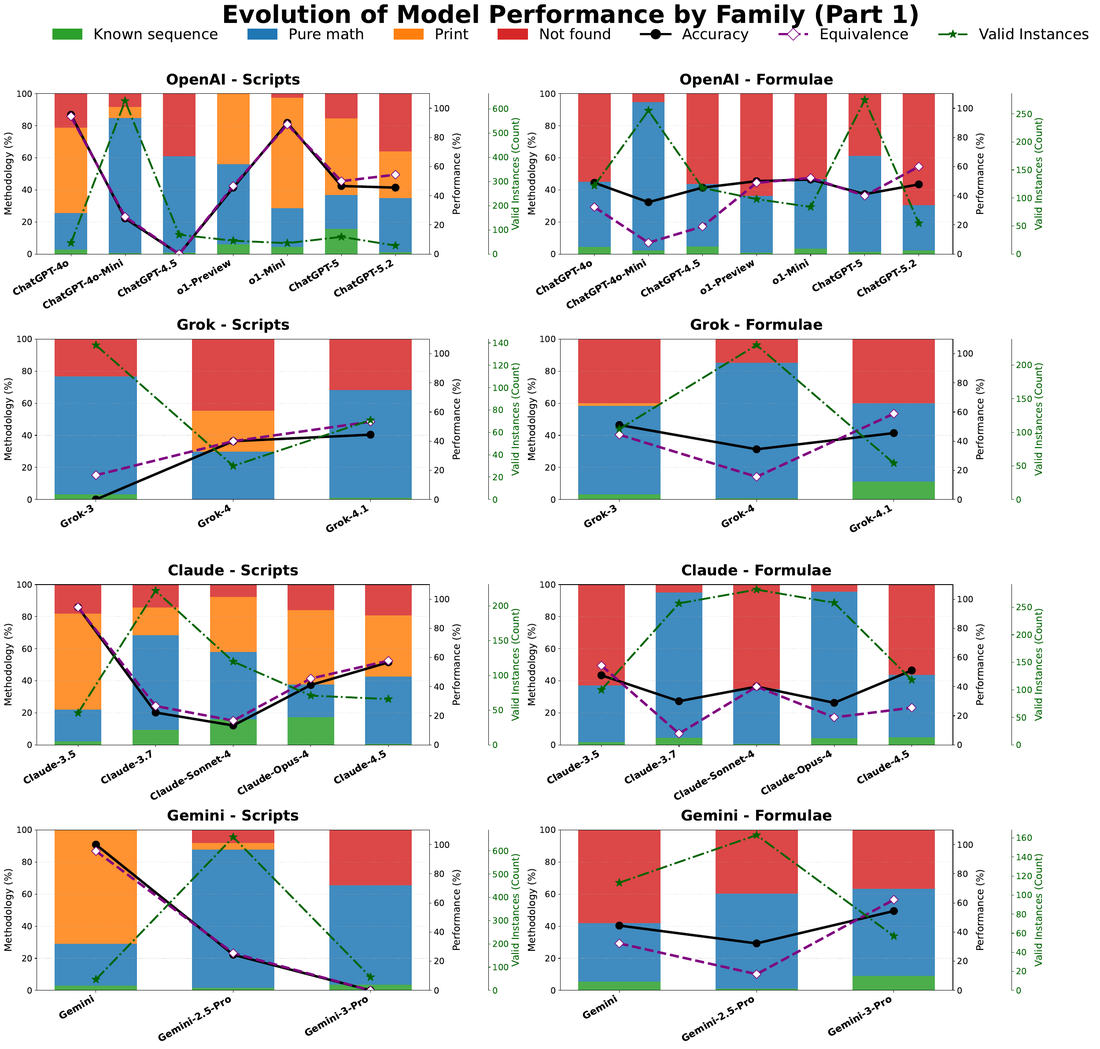

In [8]:
preview_pdf(plots_dir() / "ALL_FAMILIES_evolution_Part1.pdf")

### Supplementary Figure 6 — Part 2: Mistral, Qwen, DeepSeek, Meta

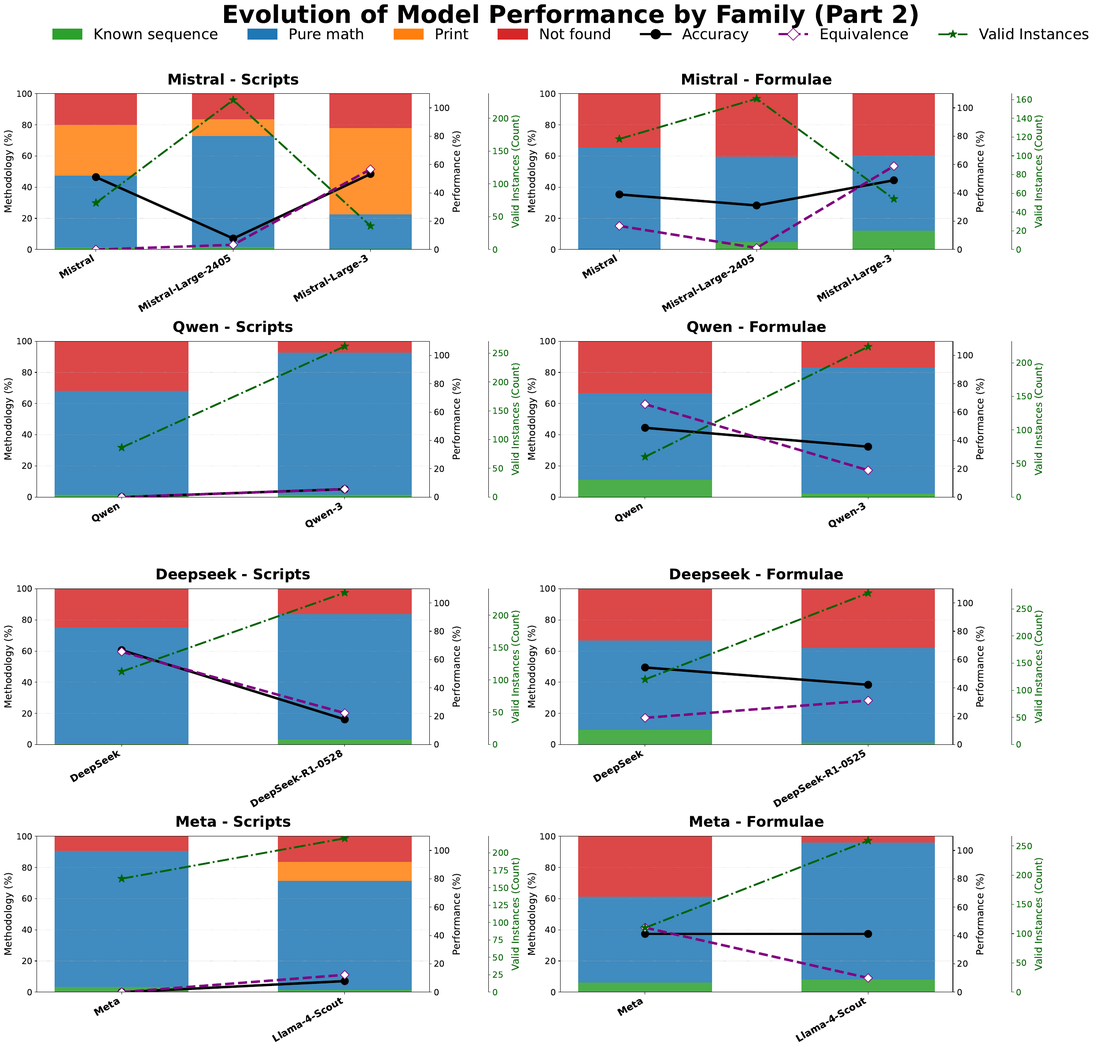

In [9]:
preview_pdf(plots_dir() / "ALL_FAMILIES_evolution_Part2.pdf")

## 6. Does it still match what was published?

Part 2 is pixel-identical to the published artifact.

Part 1 is not, and should not be: it carries the **Gemini-2.5-Pro column
correction**. The script dataset has three fully populated Gemini columns —
`gemini`, `gemini-thinking` and `gemini-2.5-pro`, holding 119, 162 and 750
programs. The name map this file used to carry sent `gemini` to the label
Gemini-2.5-Pro and had no entry for `gemini-2.5-pro` at all, so the figures
labelled the 119-program column Gemini-2.5-Pro and discarded the 750-program
one. The same defect was already corrected in the Integrated Script Analysis
(Figure 6, where valid scripts went 82 → 750); this file was missed, so the two
figures in the paper disagreed with each other about which programs are
Gemini's.

Gemini is a Part 1 family. Part 2 holds none of the affected models — and that
is the point of checking both: Part 2 coming back at 0.0000% is what shows the
Part 1 difference is the correction and not the port.


In [10]:
parity.check_figures([
    "ALL_FAMILIES_evolution_Part1.pdf",
    "ALL_FAMILIES_evolution_Part2.pdf",
])

,figure,status,detail
0,ALL_FAMILIES_evolution_Part1.pdf,changed,"SI Fig 5 family evolution, Part 1 (OpenAI, Gr..."
1,"SI Fig 6 family evolution, Part 2 (Mistral, Q...",matches published,0.0000% of pixels differ


And the published artifacts are untouched — this notebook wrote to
`outputs/`, never to `plots/`.

In [11]:
import subprocess
print(subprocess.run(["git", "status", "--porcelain", "plots/", "new_plots/"],
                     cwd=REPO_ROOT, capture_output=True, text=True).stdout or
      "(clean — no published artifact was modified)")

(clean — no published artifact was modified)
